![UTFSM](./../images/Departamento%20de%20Inform%C3%A1tica%20cromatica%20negra%404x-8.png?raw=true)

# INF-285 - Computación Científica
## Small example with GMRes
## Version: 1.02

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tclaudioe/Scientific-Computing-V3/blob/main/Bonus%20-%20current/Bonus%20-%2007%20-%20Small%20example%20with%20GMRes.ipynb)

# Table of Contents
* [Preliminary](#preliminary)
* [A small problem](#a-small-problem)
* [Finding the first approximation](#finding-the-first-approximation)
* [Finding the exception](#finding-the-exception)
* [Acknowledgements](#acknowledgements)

In [1]:
##########################
# CoLab requirements
# https://stackoverflow.com/questions/44210656/how-to-check-if-a-module-is-installed-in-python-and-if-not-install-it-within-t
##########################

# https://pypi.org/project/colorama/

import importlib.util
import sys
import subprocess
import os
    
# install_colab_requirements 
libraries = ['numpy', 'scipy', 'matplotlib', 'colorama', 
            'bitstring', 'sympy', 'ipywidgets','pandas']

for library in libraries:
    # Check if the library is already installed
    if importlib.util.find_spec(library) is not None:
        print(f"{library} is already installed.")
    else:
        print(f"{library} is not installed. Installing...")
        # Install the library using pip
        subprocess.check_call([sys.executable, "-m", "pip", "install", library])
        print(f"{library} has been installed.")
# https://stackoverflow.com/questions/53581278/test-if-notebook-is-running-on-google-colab
if os.getenv("COLAB_RELEASE_TAG"):
    print('Installing LaTeX support in CoLab')
    # Adding LaTeX dependencies to CoLab: https://stackoverflow.com/questions/55746749/latex-equations-do-not-render-in-google-colaboratory-when-using-matplotlib
    !sudo apt install cm-super dvipng texlive-latex-extra texlive-latex-recommended
else:
   print('Running on local environment')

numpy is already installed.
scipy is already installed.
matplotlib is already installed.
colorama is already installed.
bitstring is already installed.
sympy is already installed.
ipywidgets is already installed.
pandas is already installed.
Running on local environment


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

FS = 20
plt.rcParams.update({
    'font.size': FS,
    'text.usetex': True,
    'font.family': 'sans-serif',
    'font.sans-serif': 'Helvetica',
    'xtick.labelsize': FS,
    'ytick.labelsize': FS,
    'axes.labelsize': FS,
    'text.latex.preamble': r'\usepackage{amsfonts,color}'
})

def plot_components_of_first_iteration_of_GMRes(A,b,x_exact):
    plt.figure(figsize=(13,4))
    eps = 2.0
    t = np.linspace(-0.5,2.5,100)
    alpha = 0.3

    ###############################################################################
    # Computing the first step of GMRes for a 2x2 linear system of equations:
    ###############################################################################
    # Pre-allocating the memory to store Q and H
    Q = np.zeros((2,2))
    H = np.zeros((2,2))
    # Initialization of Krylov subspace: q1 = b/||b||
    q1 = b/np.linalg.norm(b)
    # Storing the first orthonormal vector q1
    Q[:,0] = q1
    
    # A@q1 = h11*q1+h21*q2

    # Computing the matrix-vector product needed.
    y = A @ q1
    # Computing the first coefficient h11 considering orthoganality
    h11 = np.dot(q1,y)
    # Substraing from the vector "y" the new known value of the right-hand-side of "A@q1 = h11*q1+h21*q2"
    # i.e. we "A@q1 - h11*q1 = h21*q2" or better said "y - h11*q1 = h21*q2"
    y -= h11*q1 # This updates the vector "y"
    # Getting h21 from computing the norm-2.
    h21 = np.linalg.norm(y)
    # Normalizing the vector new vector "y"
    q2 = y/h21

    # Storing the new values computed for h11 and h21
    H[0,0] = h11
    H[1,0] = h21
    
    # A@q2 = h12*q1+h22*q2

    # Computing matrix vector product,
    y = A @ q2
    # Computing first coefficients.
    h12 = np.dot(q1,y)
    # Moving to the left hand side the known value.
    y -= h12*q1
    # Computing the last coefficient.
    h22 = np.dot(q2,y)

    # Storing them.
    H[0,1] = h12
    H[1,1] = h22
    
    # Getting just the first columns of H_tilde
    H1_tilde = H[:,0]
    # Computing the vector ||b||*e1
    rhs1 = np.array([np.linalg.norm(b),0.0])

    # QR factorization of H1_tilde - since it is a vector, we can do the QR factorization directly
    R1_ls = np.linalg.norm(H1_tilde)
    Q1_ls = H1_tilde/R1_ls

    # Solving the least-square problem
    c1 = np.dot(Q1_ls,rhs1)/R1_ls
    # Computing the solution, which is c1*q1
    x1 = c1*q1
    
    ###############################################################################
    # Computing residuals
    ###############################################################################
    Ax1 = A@x1
    res_b_Ax1 = b-Ax1
    res_rhs1_H1_tilde= rhs1-c1*H1_tilde
    res_x_exact_x1 = x_exact-x1

    ###############################################################################
    # Plotting
    ###############################################################################
    plt.subplot(131)
    ax = plt.gca()
    cos_theta1 = np.dot(res_b_Ax1,Ax1)/(np.linalg.norm(res_b_Ax1)*np.linalg.norm(Ax1))
    ax.set_title(r'$\mathrm{Original\ Least-Square\ problem}$'+'\n'
                +r'$\mathrm{where\ }$'
                +r'$\cos\left(\mathbf{r},A\,\mathbf{x}_1\right)=$'+
                f'$%.3f$'%(cos_theta1), fontsize=14)
    ax.plot([],[], color='blue', label=r'$\mathbf{b}$')
    ax.plot([],[], color='magenta', label=r'$A\,\mathbf{x}_1=A\,\mathbf{q}_1\,c_1$',)
    ax.plot([],[], color='black', label=r'$\mathbf{r}=\mathbf{b}-A\,\mathbf{x}_1$')
    ax.legend(loc='upper left', fontsize=14, labelcolor='linecolor', bbox_to_anchor=(0.0, -0.12), fancybox=True, shadow=True, ncol=1)

    #######################################
    ax.quiver(0, 0, b[0], b[1], angles='xy', scale_units='xy', scale=1, units='x',color='blue')
    #######################################
    ax.quiver(0, 0, Ax1[0], Ax1[1], angles='xy', scale_units='xy', scale=1, units='x',color='magenta')
    #######################################
    ax.quiver(Ax1[0], Ax1[1], res_b_Ax1[0], res_b_Ax1[1], angles='xy', scale_units='xy', scale=1, units='x',color='black')
    #######################################
    K1_subspace = ((A@Q[:,0])[:,np.newaxis]*t[np.newaxis,:]).T
    ax.plot(K1_subspace[:,0],K1_subspace[:,1],'r--',alpha=alpha)
    #######################################
    ax.set_xlim((np.min(np.array([0.0, b[0], Ax1[0]])-eps),np.max(np.array([2.0, b[0], Ax1[0]])+eps)))
    ax.set_ylim((np.min(np.array([0.0, b[1], Ax1[1]])-eps),np.max(np.array([2.0, b[1], Ax1[1]])+eps)))
    ax.axis('equal')
    ax.grid(True)

    ############################################################
    plt.subplot(132)
    ax = plt.gca()
    cos_theta2 = np.dot(res_rhs1_H1_tilde,c1*H1_tilde)/(np.linalg.norm(res_rhs1_H1_tilde)*np.linalg.norm(c1*H1_tilde))
    ax.set_title(r'$\mathrm{Small\ Least-Square\ problem}$'+'\n'
                +r'$\mathrm{where\ }$'
                +r'$\cos\left(\mathbf{r}_{\mathrm{small}},c_1\,\mathbf{h}_1\right)=$'+
                f'$%.3f$'%(cos_theta2), fontsize=14)
    ax.plot([],[], color='blue', label=r'$\|\mathbf{b}\|\,\mathbf{e}_1$')
    ax.plot([],[], color='magenta', label=r'$c_1\,\mathbf{h}_1$')
    ax.plot([],[], color='black', label=r'$\mathbf{r}_{\mathrm{small}}=\|\mathbf{b}\|\,\mathbf{e}_1-c_1\,\mathbf{h}_1$')
    ax.legend(loc='upper left', fontsize=14, labelcolor='linecolor', bbox_to_anchor=(0.0, -0.12), fancybox=True, shadow=True, ncol=1)

    #######################################
    ax.quiver(0, 0, rhs1[0], rhs1[1], angles='xy', scale_units='xy', scale=1, units='x',color='blue')
    #######################################
    ax.quiver(0, 0, c1*H1_tilde[0], c1*H1_tilde[1], angles='xy', scale_units='xy', scale=1, units='x',color='magenta')
    #######################################
    ax.quiver(c1*H1_tilde[0], c1*H1_tilde[1], res_rhs1_H1_tilde[0], res_rhs1_H1_tilde[1], angles='xy', scale_units='xy', scale=1, units='x',color='black')
    #######################################
    K1_subspace = ((H1_tilde)[:,np.newaxis]*t[np.newaxis,:]).T
    ax.plot(K1_subspace[:,0],K1_subspace[:,1],'r--',alpha=alpha)
    #######################################
    ax.set_xlim((np.min(np.array([0.0, rhs1[0], c1*H1_tilde[0]])-eps),np.max(np.array([2.0, rhs1[0], c1*H1_tilde[0]])+eps)))
    ax.set_ylim((np.min(np.array([0.0, rhs1[1], c1*H1_tilde[1]])-eps),np.max(np.array([2.0, rhs1[1], c1*H1_tilde[1]])+eps)))
    ax.axis('equal')
    ax.grid(True)

    ############################################################
    plt.subplot(133)
    ax = plt.gca()
    cos_theta3 = np.dot(res_x_exact_x1,x1)/(np.linalg.norm(res_x_exact_x1)*np.linalg.norm(x1)) 
    ax.set_title(r'$\mathrm{Comparison\ between\ exact\ } \mathbf{x}_{\mathrm{exact}} \mathrm{\ and\ } \mathbf{x}_1$'+'\n'
                +r'$\mathrm{where\ }$'
                +r'$\cos\left(\mathbf{r}_{\mathrm{error}},\mathbf{x}_1\right)=$'+
                f'$%.3f$'%(cos_theta3), fontsize=14)
    ax.plot([],[], color='blue', label=r'$\mathbf{x}_{\mathrm{exact}}$')
    ax.plot([],[], color='magenta', label=r'$\mathbf{x}_1=\mathbf{q}_1\,c_1$')
    if np.abs(cos_theta3)<1e-3:
        ax.plot([],[], color='red', label=r'$\mathbf{r}_{\mathrm{error}}=\mathbf{x}_{\mathrm{exact}}-\mathbf{x}_1$')
    else:
        ax.plot([],[], color='red', label=r'$\mathbf{r}_{\mathrm{error}}=\mathbf{x}_{\mathrm{exact}}-\mathbf{x}_1$') 
    ax.legend(loc='upper left', fontsize=14, labelcolor='linecolor', bbox_to_anchor=(0.0, -0.12), fancybox=True, shadow=True, ncol=1)

    #######################################
    ax.quiver(0, 0, x_exact[0], x_exact[1], angles='xy', scale_units='xy', scale=1, units='x',color='blue')
    #######################################
    ax.quiver(0, 0, x1[0], x1[1], angles='xy', scale_units='xy', scale=1, units='x',color='magenta')
    #######################################
    if np.abs(cos_theta3)<1e-3:
        ax.quiver(x1[0], x1[1], res_x_exact_x1[0], res_x_exact_x1[1], angles='xy', scale_units='xy', scale=1, units='x',color='black')
    else:
        ax.quiver(x1[0], x1[1], res_x_exact_x1[0], res_x_exact_x1[1], angles='xy', scale_units='xy', scale=1, units='x',color='red') 
    #######################################
    K1_subspace = ((x1)[:,np.newaxis]*t[np.newaxis,:]).T
    ax.plot(K1_subspace[:,0],K1_subspace[:,1],'r--',alpha=alpha)
    #######################################
    ax.set_xlim((np.min(np.array([0.0, x_exact[0], x1[0]])-eps),np.max(np.array([2.0, x_exact[0], x1[0]])+eps)))
    ax.set_ylim((np.min(np.array([0.0, x_exact[1], x1[1]])-eps),np.max(np.array([2.0, x_exact[1], x1[1]])+eps)))
    ax.axis('equal')
    ax.grid(True)

    plt.subplots_adjust(wspace=0.2)
    plt.show()

# Preliminary
[Back to TOC](#table-of-contents)

This Jupyter Notebook aims to analyze the ortogonality condition for the residuals obstained and we will also comparte to the exact solution.
For _extreme_ simplicity, we will solve a linear system of equations of $2\times 2$.
This small problem, allows us to observe graphically what happens when we only use 1 vector from the Krylov subspace.

In this case, we get the identity $A\,\mathbf{q}_1=Q_2\,\widetilde{H}_1$ and we consider $\mathbf{x}\in\mathcal{K}_1$ can be parametrized by $c_1\,\mathbf{q}_1$:
$$
\begin{align*}
    \min_{\mathbf{x}\in \mathcal{K}_1} \left\| \mathbf{b}-A\,\mathbf{x} \right\|_2^2
    &=
    \min_{c_1\in \mathbb{R}} \left\| \mathbf{b}
        -A\,\left(c_1\,\mathbf{q}_1\right)
        \right\|_2^2\\
    &=
    \min_{c_1\in \mathbb{R}} \left\| \mathbf{b}
        -A\,\mathbf{q}_1\,c_1
        \right\|_2^2\\
    &=
    \min_{c_1\in \mathbb{R}} \left\| \mathbf{b}
        -Q_2\,\widetilde{H}_1\,c_1
        \right\|_2^2\\
    &=
    \min_{c_1\in \mathbb{R}} \left\| \begin{bmatrix} \|\mathbf{b}\|\\ 0\end{bmatrix}
        -\widetilde{H}_1\,c_1
        \right\|_2^2\\
    &=
    \min_{c_1\in \mathbb{R}} \left\| \begin{bmatrix} \|\mathbf{b}\|\\ 0\end{bmatrix}
        -\begin{bmatrix} h_{1,1} \\ h_{2,1}\end{bmatrix}\,c_1
        \right\|_2^2\\
\end{align*}
$$

Thus, we will compare the following quantities,
- Residual of the _original_ problem:
$$
    \min_{\mathbf{x}\in \mathcal{K}_1} \left\| \mathbf{b}-A\,\mathbf{x} \right\|_2^2
$$
- Residual of the _small_ problem after 1 iteration of GMRes:
$$
   \min_{c_1\in \mathbb{R}} \left\| \begin{bmatrix} \|\mathbf{b}\|\\ 0\end{bmatrix}
        -\begin{bmatrix} h_{1,1} \\ h_{2,1}\end{bmatrix}\,c_1
        \right\|_2^2 
$$
- Error between the exact solution $\mathbf{x}_{\mathrm{exact}}$ and $\mathbf{x}_1$:
$$
   \left\|\mathbf{x}_{\mathrm{exact}} - \mathbf{x}_1 \right\|_2^2
$$
where $\mathbf{x}_1\in\mathcal{K}_1$.

# A small problem
[Back to TOC](#table-of-contents)

$$
\begin{bmatrix}
    2 & -1 \\
    3 & 3
\end{bmatrix}
\mathbf{x} =
\begin{bmatrix}
    1 \\
    6
\end{bmatrix}
$$
which has exact solution equal to $\mathbf{x}_{\mathrm{exact}}=\begin{bmatrix}1\\1\end{bmatrix}$.

In [3]:
A = np.array([[2.,-1],[3,3]])
x_exact = np.array([1,1])

# Notice that we build the right-hand-side this way so
# when we solve A*x=b we know in advance the exact solution x_exact.
b = A @ x_exact

In [4]:
# Pre-allocating the memory to store Q and H
Q = np.zeros((2,2))
H = np.zeros((2,2))

# Initialization of Krylov subspace: q1 = b/||b||
q1 = b/np.linalg.norm(b)

# Storing the first orthonormal vector q1
Q[:,0] = q1

Now, the next step is to compute the second vector of the Krylov subspace, i.e. $\mathbf{q}_2$.
The $\textrm{\color{red}unknown}$ terms are the terms in $\textrm{\color{red}red}$ and the $\textrm{\color{blue}known}$ terms are in $\textrm{\color{blue}blue}$,
$$
{\color{blue} A\,\mathbf{q}_1} = {\color{red} h_{11}}\,{\color{blue} \mathbf{q}_1}+{\color{red}h_{21}\,\mathbf{q}_2}.
$$
Notice that an alternative notation is,
$$
{\color{blue} A} \,\underbrace{{\color{blue}Q_1}}_{\displaystyle{\begin{bmatrix}{\color{blue}\mathbf{q}_1 }\end{bmatrix}}} = \underbrace{\begin{bmatrix} {\color{blue} \mathbf{q}_1} & {\color{red}\mathbf{q}_2} \end{bmatrix}}_{\displaystyle Q_2}
                        \underbrace{\begin{bmatrix} {\color{red} h_{11}}\\ {\color{red}h_{21}}\end{bmatrix}}_{\displaystyle {\color{red} \widetilde{H}_1 }}.
$$

The following code computes the $\textrm{\color{red}unknown}$ terms using the unrolled Arnoldi iteration:

In [5]:
# A@q1 = h11*q1+h21*q2

# Computing the matrix-vector product needed.
y = A @ q1
# Computing the first coefficient h11 considering orthoganality
h11 = np.dot(q1,y)
# Substraing from the vector "y" the new known value of the right-hand-side of "A@q1 = h11*q1+h21*q2"
# i.e. we "A@q1 - h11*q1 = h21*q2" or better said "y - h11*q1 = h21*q2"
y -= h11*q1 # This updates the vector "y"
# Getting h21 from computing the norm-2.
h21 = np.linalg.norm(y)
# Normalizing the vector new vector "y"
q2 = y/h21

# Storing the new values computed for h11 and h21
H[0,0] = h11
H[1,0] = h21

The next step is to compute the "last" iteration of GMRes for this 2x2 linear system of equations.
In this case we get the following identity:
$$
{\color{blue} A\,\mathbf{q}_2} = 
    {\color{red} h_{12}}\,{\color{blue} \mathbf{q}_1}
    +
    {\color{red} h_{22}}\,{\color{blue} \mathbf{q}_2}.
$$

This allow of to write the **final** identity:
$$
{\color{blue} A\,Q_2} = \underbrace{\begin{bmatrix} {\color{blue} \mathbf{q}_1} & {\color{blue} \mathbf{q}_2} \end{bmatrix}}_{\displaystyle {\color{blue} Q_2 }}
                        \underbrace{\begin{bmatrix} {\color{blue} h_{11}} & {\color{red} h_{12}} \\ {\color{blue}h_{21}} & {\color{red}h_{22}} \end{bmatrix}}_{\displaystyle \widetilde{H}_2}.
$$

The following code compute the final coefficients $h_{12} and $h_{22}$,

In [6]:
# A@q2 = h12*q1+h22*q2

# Computing matrix vector product,
y = A @ q2
# Computing first coefficients.
h12 = np.dot(q1,y)
# Moving to the left hand side the known value.
y -= h12*q1
# Computing the last coefficient.
h22 = np.dot(q2,y)

# Storing them.
H[0,1] = h12
H[1,1] = h22

# Finding the first approximation
[Back to TOC](#table-of-contents)

$$
\begin{align*}
    \min_{\mathbf{x}\in \mathcal{K}_1} \left\| \mathbf{b}-A\,\mathbf{x} \right\|_2^2
    &=
    \min_{c_1\in \mathbb{R}} \left\| \begin{bmatrix} \|\mathbf{b}\|\\ 0\end{bmatrix}
        -\begin{bmatrix} h_{1,1} \\ h_{2,1}\end{bmatrix}\,c_1
        \right\|_2^2\\
\end{align*}
$$
Recall that in this case the expression of the right-hand-side is a _tradicional_ least-square problema and can be solve the tradicional way, i.e. with the normal equations or with the **recommended** QR factorization!

Notice that for this particular problem, since the _matrix_ of the small least-square problem is just a vector, we will use just the normal equations.

In [7]:
# Getting just the first columns of H_tilde
H1_tilde = H[:,0]
# Computing the vector ||b||*e1
rhs1 = np.array([np.linalg.norm(b),0.0])

# QR factorization of H1_tilde - since it is a vector, we can do the QR factorization directly
R1_ls = np.linalg.norm(H1_tilde)
Q1_ls = H1_tilde/R1_ls

# Solving the least-square problem
c1 = np.dot(Q1_ls,rhs1)/R1_ls
# Computing the solution, which is c1*q1
x1 = c1*q1

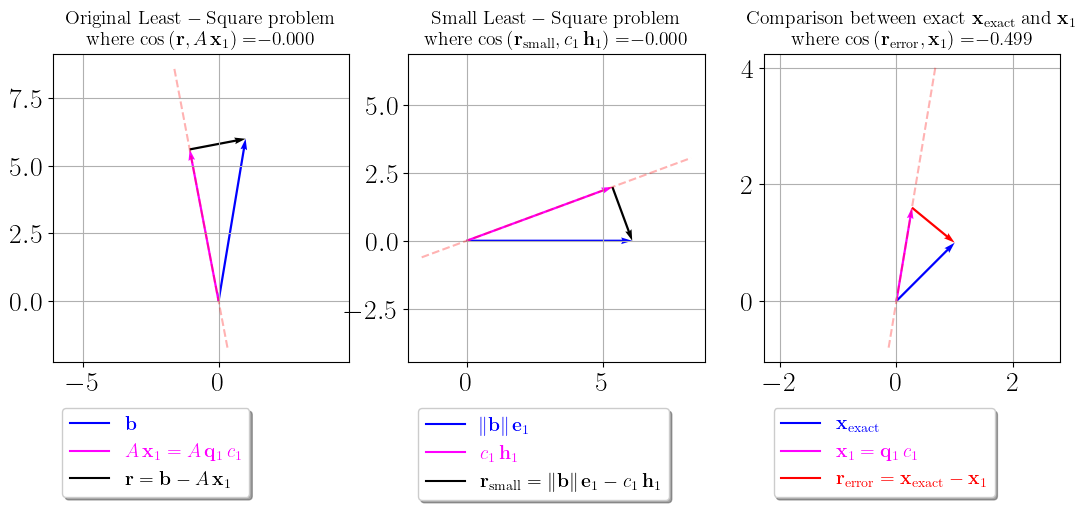

In [8]:
plot_components_of_first_iteration_of_GMRes(A,b,x_exact)

The previous numerical experiment was performed for the particular linear system of equations used, i.e.
$$
\begin{bmatrix}
    2 & -1 \\
    3 & 3
\end{bmatrix}
\mathbf{x} =
\begin{bmatrix}
    1 \\
    6
\end{bmatrix}
$$
which has exact solution equal to $\mathbf{x}_{\mathrm{exact}}=\begin{bmatrix}1\\1\end{bmatrix}$.
This small problem show the behaviour we are looking for, i.e.,
- The vectors $\textcolor{black}{\mathbf{r}}$ and $\textcolor{magenta}{A\,\mathbf{x}_1}$ are **orthogonals** since $\cos\left(\mathbf{r},A\,\mathbf{x}_1\right)=0$.
- The vectors $\textcolor{black}{\mathbf{r}_{\mathrm{small}}}$ and $\textcolor{magenta}{c_1\,\mathbf{h}_1}$ are **orthogonals** since $\cos\left(\mathbf{r}_{\mathrm{small}},c_1\,\mathbf{h}_1\right)=0$.

On the other hand,
- The vectors $\textcolor{red}{\mathbf{r}_{\mathrm{error}}=\mathbf{x}_{\mathrm{exact}-\mathrm{x}_1}}$ and $\textcolor{magenta}{\mathbf{x}_1=c_1\,\mathbf{q}_1}$ are **not necessarily orthogonal**.

Recall that cosine of the angle, say $\theta$, between two vectors can be computed as follows,
$$
\cos(\theta)=\dfrac{\langle \mathbf{a},\mathbf{b} \rangle}{\|\mathbf{a}\|_2\,\|\mathbf{b}\|_2},
$$
where $\langle \mathbf{a},\mathbf{b} \rangle$ is the inner product (a.k.a. dot product) between the vectors $\mathbf{a}$ and $\mathbf{b}$.
From this expresion, we can define the cosine of two vectors, which corresponds to,
$$
\cos\left(\mathbf{a},\mathbf{b}\right) = \cos(\theta)=\dfrac{\langle \mathbf{a},\mathbf{b} \rangle}{\|\mathbf{a}\|_2\,\|\mathbf{b}\|_2}. 
$$
Therefore, the cosine of two vectors is the cosine of the angle between them.
In particular, if the cosine of two vectors is $0$, then we can conclude the angle between them is equal to $\dfrac{\pi}{2}$, i.e. the two vectors are orthogonal.
_Thus, this is the reason we showed in the title of the plots the cosine of two vector in the previous numerical experiment_. 

# Finding the exception
[Back to TOC](#table-of-contents)

The following numerical experiment modifies one coefficient of the original matrix $A$.
The new matrix will be,
$$
A = 
\begin{bmatrix}
    2 & -1\\
    \rho & 3
\end{bmatrix},
$$
with this in mind,

**Would it be possible to find a value for $\rho$ such that $\textcolor{red}{\mathbf{r}_{\mathrm{error}}=\mathbf{x}_{\mathrm{exact}-\mathrm{x}_1}}$ and $\textcolor{magenta}{\mathbf{x}_1=c_1\,\mathbf{q}_1}$ are ortogonals?**

In [9]:
def getting_orthogonal_r_error(rho=1.0):
    
    print('rho:',rho)
    A = np.array([[2.,-1],[rho,3]])
    
    print('det(A):',np.linalg.det(A))
    
    print('New Matrix A:',A)
    
    x_exact = np.array([1,1])
    b = A @ x_exact
    
    plot_components_of_first_iteration_of_GMRes(A,b,x_exact)

interact(getting_orthogonal_r_error,rho=(-2,2,0.005))

interactive(children=(FloatSlider(value=1.0, description='rho', max=2.0, min=-2.0, step=0.005), Output()), _do…

<function __main__.getting_orthogonal_r_error(rho=1.0)>

# Acknowledgements
[Back to TOC](#table-of-contents)

* _Material created by professor Claudio Torres_ (`claudio.torres@usm.cl`). _DI UTFSM. November 2025._
* _Update November 2025 - v1.01 - C.Torres_ : Adding definition of the cosine of two vectors.
* _Update November 2025 - v1.02 - C.Torres_ : Adding colab link.
